# RGB Thresholding

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

(1280, 1920, 3)


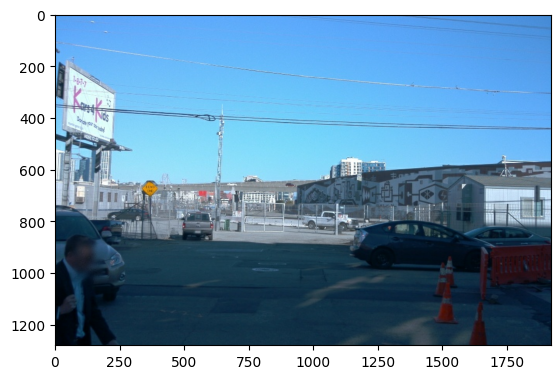

In [2]:
# Note: OpenCV loads images as BGR by default, but the logic is the same.
# We will assume a BGR/RGB image array with shape (H, W, 3)
original_image = cv2.imread('data/images/segment-1231623110026745648_480_000_500_000_with_camera_labels_38 copy.png')

# Convert to standard RGB for intuitive channel order matching the threshold
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

print(original_image.shape)
plt.imshow(original_image)

In [3]:
## --- STEP 2: Define Threshold and Comparison Type ---
# Define the threshold color (e.g., medium gray)
threshold_color = np.array([128, 128, 128], dtype=np.uint8)

In [4]:
# Get the three channels from the image array
# This assumes the order is BGR or RGB depending on how the image was loaded
R, G, B = cv2.split(original_image) #if 'cv2' in locals() else original_image[:, :, 0], original_image[:, :, 1], original_image[:, :, 2]
T_R, T_G, T_B = threshold_color

print(R.shape)

(1280, 1920)


In [5]:
## --- STEP 3: Create the Binary Mask (Isolated Pixels) ---

# A. Isolate pixels where ALL channels are HIGHER than the threshold
mask_condition_B = B > T_B
mask_condition_G = G > T_G
mask_condition_R = R > T_R

print(mask_condition_B)

[[ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]


In [6]:
# Combine conditions using logical AND (&)
# The final mask is True only where a pixel's (B AND G AND R) are all > threshold
binary_mask_bool = mask_condition_R & mask_condition_G & mask_condition_B

In [7]:
# Convert boolean mask to 0s and 255s (standard for displaying masks)
binary_mask = binary_mask_bool.astype(np.uint8) * 255

print(binary_mask.shape)

(1280, 1920)


In [8]:
## --- STEP 4: Apply the Mask to Create the Masked Image ---

# Create a copy of the original image
masked_image = original_image.copy()

# The masked image is created by setting pixels to black (0, 0, 0) where the mask is False
# For NumPy masking, we use the NOT operator (~) on the boolean mask
masked_image[~binary_mask_bool] = [0, 0, 0] 

# Note: If you want to set the background to a specific color (like white), 
# you would set masked_image[~binary_mask_bool] = [255, 255, 255]

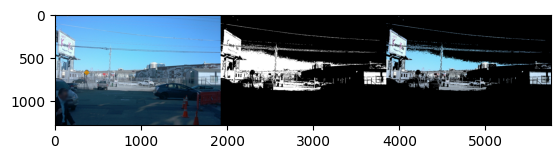

In [10]:
## --- STEP 5: Display Results ---
# Only run this section if OpenCV is available and you want to visualize
if 'cv2' in locals():
    # Stack the images horizontally for comparison
    comparison = np.hstack([original_image, cv2.cvtColor(binary_mask, cv2.COLOR_GRAY2BGR), masked_image])
    
    plt.imshow(comparison)
else:
    print("\n--- Original Image (Partial) ---")
    print(original_image)
    print("\n--- Binary Mask (Boolean True/False) ---")
    print(binary_mask_bool.astype(int))
    print("\n--- Masked RGB Image (Black Background) ---")
    print(masked_image)